# Session 10: Hierarchical Models & Partial Pooling

**Bayesian Analysis of Empirical Data (2026)**  
*Author: Irina Knyazeva*

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/iknyazeva/bayes-cogsci-book/blob/main/notebooks/colab/10_hierarchical_models_partial_pooling.ipynb)

In experimental cognitive science and psychology, observations are structured within human participants and experimental stimuli. Hierarchical models use **partial pooling** to share statistical information adaptively across units. In this lab, we implement the classic Prosocial Chimpanzees model (Silk et al., 2005; McElreath, *Statistical Rethinking* Ch. 11/13).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
import pymc as pm

plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
rng = np.random.default_rng(2026)

# Synthetic replica of Chimpanzee Prosocial choice dataset (7 actors, N = 504 trials)
J_actors = 7
trials_per_actor = 72
actor_id = np.repeat(np.arange(J_actors), trials_per_actor)

# True actor varying intercepts
alpha_true = rng.normal(0.0, 1.2, size=J_actors)
prosoc_left = rng.binomial(1, 0.5, size=len(actor_id))
condition = rng.binomial(1, 0.5, size=len(actor_id))

logit_p = alpha_true[actor_id] + 0.4 * prosoc_left + 0.35 * condition * prosoc_left
pulled_left = rng.binomial(1, 1.0 / (1.0 + np.exp(-logit_p)))

df_chimp = pd.DataFrame({"actor": actor_id, "pulled_left": pulled_left, "condition": condition, "prosoc_left": prosoc_left})
df_chimp.head()

,actor,pulled_left,condition,prosoc_left
0,0,0,0,0
1,0,1,1,1
2,0,0,0,0
3,0,1,1,1
4,0,1,1,1


## 1. Fitting Partial Pooling with Non-Centered Varying Intercepts in PyMC

In [2]:
with pm.Model() as chimp_partial_pooling:
    # Hyper-priors on population of actors
    mu_alpha = pm.Normal("mu_alpha", mu=0.0, sigma=1.0)
    sigma_actor = pm.Exponential("sigma_actor", 1.0)
    
    # Non-centered parameterization to avoid divergences
    z_actor = pm.Normal("z_actor", mu=0.0, sigma=1.0, shape=J_actors)
    alpha_actor = pm.Deterministic("alpha_actor", mu_alpha + z_actor * sigma_actor)
    
    # Treatment effect
    beta_treat = pm.Normal("beta_treat", mu=0.0, sigma=0.5)
    
    # Likelihood
    logit_p = alpha_actor[df_chimp["actor"].values] + beta_treat * df_chimp["prosoc_left"].values
    y_obs = pm.Bernoulli("pulled_left", logit_p=logit_p, observed=df_chimp["pulled_left"].values)
    
    idata_chimp = pm.sample(draws=1000, tune=1000, chains=4, random_seed=2026, return_inferencedata=True)

print(az.summary(idata_chimp, var_names=["mu_alpha", "sigma_actor", "beta_treat"])[["mean", "sd", "hdi_3%", "hdi_97%", "r_hat"]])

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [mu_alpha, sigma_actor, z_actor, beta_treat]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


              mean     sd  hdi_3%  hdi_97%  r_hat
mu_alpha    -0.246  0.474  -1.116    0.746   1.01
sigma_actor  1.352  0.422   0.689    2.121   1.00
beta_treat   0.748  0.192   0.383    1.100   1.00


## 2. Visualizing Adaptive Shrinkage Across Actors

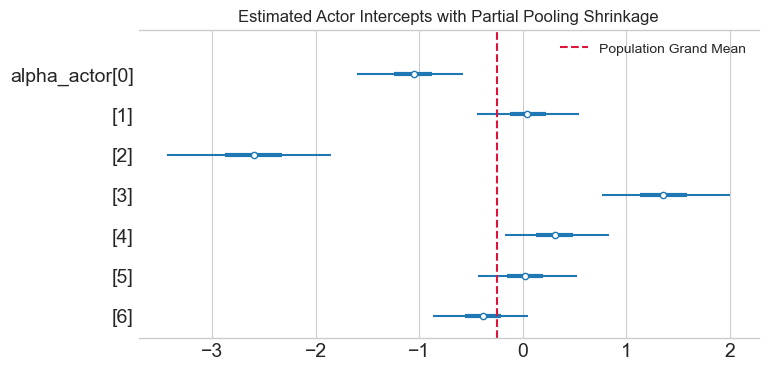

In [3]:
az.plot_forest(idata_chimp, var_names=["alpha_actor"], combined=True, figsize=(8, 4))
plt.axvline(idata_chimp.posterior["mu_alpha"].values.mean(), color="crimson", ls="--", label="Population Grand Mean")
plt.title("Estimated Actor Intercepts with Partial Pooling Shrinkage")
plt.legend()
plt.show()